In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [51]:
df = df[df['room_type'] == 'Private room']

In [52]:
df['bathrooms_text'].head()

4     1 private bath
6     1 private bath
9          1.5 baths
10     1 shared bath
11    1 private bath
Name: bathrooms_text, dtype: object

In [53]:
df['bathrooms_text'] = df['bathrooms_text'].str.replace('private bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared bath', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared baths', '', regex=False)
df['bathrooms_text'] = df['bathrooms_text'].str.replace('shared', '', regex=False)


In [54]:
df = df.dropna(subset=['bathrooms_text'])

In [55]:
df['bathrooms_text'] = pd.to_numeric(df['bathrooms_text'], errors='coerce')

In [56]:
df['bathrooms_text'] = df['bathrooms_text'].astype(float)

C:\Users\issei\AppData\Local\Temp\ipykernel_50900\1786923915.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


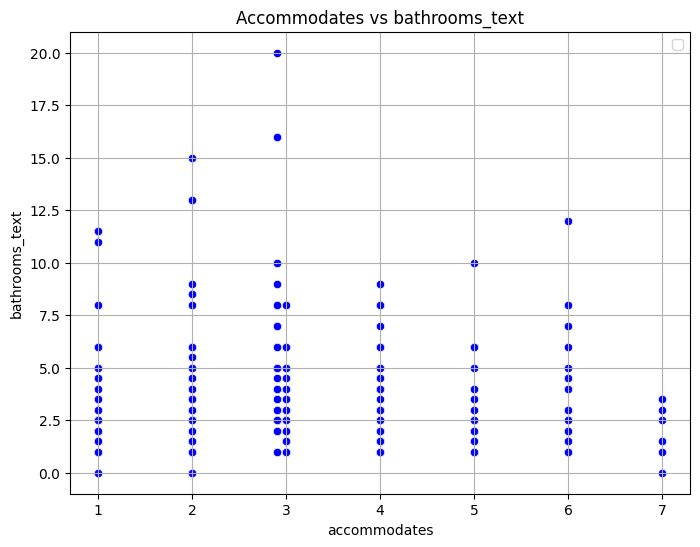

In [66]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(x='accommodates', y='bathrooms_text',  color = 'blue', data=df)
plt.title('Accommodates vs bathrooms_text')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
indep= df[['bathrooms_text']]
dep = df[['accommodates']]

In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [69]:
df = df.dropna()

In [70]:
model.fit(indep, dep)

LinearRegression()

In [71]:
type(model)

sklearn.linear_model._base.LinearRegression

In [72]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['bathrooms_text'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[0.07878816]]),
 'rank_': 1,
 'singular_': array([89.58883603]),
 'intercept_': array([1.83073767])}

In [73]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[0.07878816]]
Intercepto: [1.83073767]
y = [0.07878816]x + [1.83073767]


In [74]:
r2 = model.score(indep, dep)
r2

0.007537789865604161

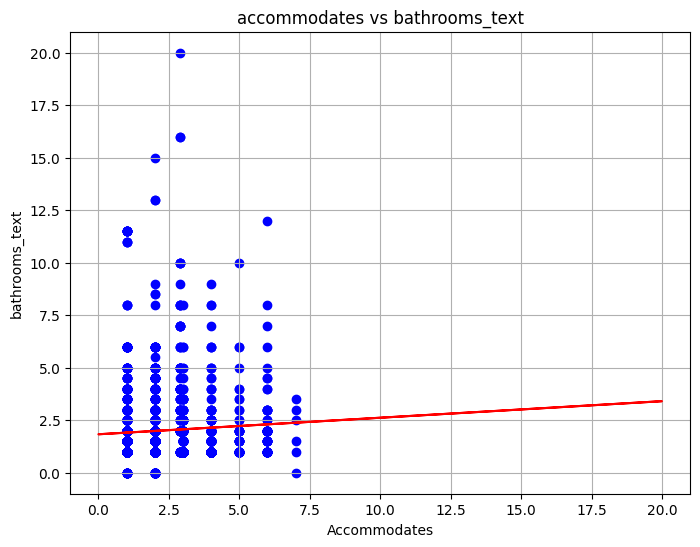

In [75]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('accommodates vs bathrooms_text')
plt.xlabel('Accommodates')
plt.ylabel('bathrooms_text')
plt.grid(True)
plt.show()

In [76]:
yPred = model.predict(df[['bathrooms_text']])
yPred

array([[1.90952583],
       [1.90952583],
       [1.94891991],
       ...,
       [1.90952583],
       [1.90952583],
       [1.90952583]])

In [77]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17,1.909526
6,7,171109,816295,1,1,city scrape,Cool room near WTC and Metrobus,"Stay in a private room 2 blocks away from WTC,...","Great location, feel comfortable and secure at...",Carlos,...,0.0,4.84,4.87,4.61,4.98,4.95,4.97,4.81,0.84,1.909526
9,10,1013504,1664327,1,1,city scrape,"OASIS IN COYOACAN, SHARED HOUSE",Private room (single bed) with private bathro...,"Her It's very safe, there are some restaurants...",Edoardo,...,1.0,4.96,4.90,4.92,4.92,4.94,4.92,4.89,0.54,1.948920
10,11,1051636,22366411,1,1,city scrape,Chilango chic: room historic Condesa DF,"Like home! Private room in charming, tasteful ...",In the heart of the real Condesa! Chic yet sti...,Citlalli,...,0.0,4.83,4.60,4.97,4.97,4.77,4.93,4.73,0.22,1.909526
11,12,1066945,5870021,1,1,city scrape,"Villa Alfonsina, Heart of Coyoacan",In front of the Frida Kahlo Museum.<br /> Priv...,"Our street ""Allende"" is privileged as it is on...",Héctor,...,0.0,4.93,4.94,4.97,4.96,4.91,4.97,4.94,1.15,1.909526


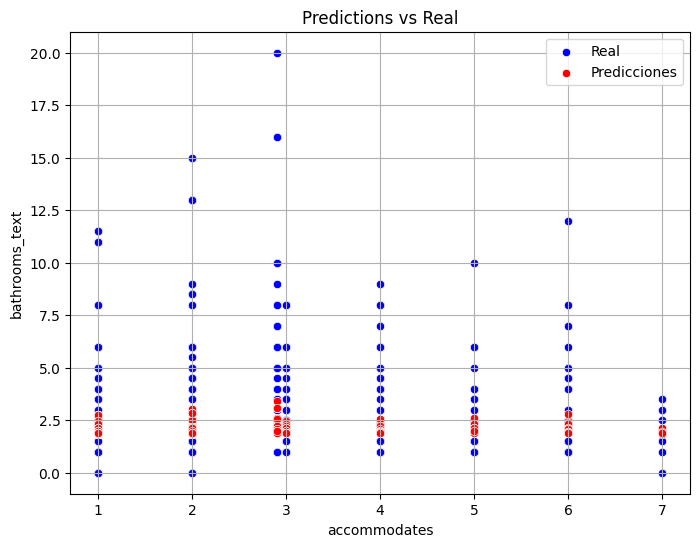

In [78]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='accommodates', y='bathrooms_text', color='blue', data=df, label='Real')
sns.scatterplot(x='accommodates', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('accommodates')
plt.ylabel('bathrooms_text')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
coefDe = model.score(indep, dep)
coefDe

0.007537789865604161

In [80]:
coefCo = np.sqrt(coefDe)
coefCo

0.08682044612649811